Starts here

It takes took much time to run (about 3hrs)!!

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random


data_file = "tiny_shakespeare.txt"
if not os.path.exists(data_file):
    raise FileNotFoundError("File 'tiny_shakespeare.txt' not found in the current directory.")

with open(data_file, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Dataset length: {len(text)} characters.")


chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Unique characters: {vocab_size}")

char_to_idx = { ch: i for i, ch in enumerate(chars) }
idx_to_char = { i: ch for i, ch in enumerate(chars) }


encoded_data = [char_to_idx[c] for c in text]


sequence_length = 100
inputs = []
targets = []
for i in range(len(encoded_data) - sequence_length):
    inputs.append(encoded_data[i:i+sequence_length])
    targets.append(encoded_data[i+1:i+sequence_length+1])
inputs = torch.tensor(inputs, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

batch_size = 128
dataset = TensorDataset(inputs, targets)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Vanilla RNN model re-implementing Torch-rnn's structure
class VanillaRNNModel(nn.Module):
    def __init__(self, input_size, rnn_size, num_layers, dropout=0.0):
        """
        Args:
            input_size: Size of the input (vocabulary size, since inputs are one-hot).
            rnn_size: Hidden state size.
            num_layers: Number of stacked RNN layers.
            dropout: Dropout probability.
        """
        super(VanillaRNNModel, self).__init__()
        self.input_size = input_size
        self.rnn_size = rnn_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.i2h = nn.ModuleList()
        self.h2h = nn.ModuleList()
        for layer in range(num_layers):
            if layer == 0:
                self.i2h.append(nn.Linear(input_size, rnn_size))
            else:
                self.i2h.append(nn.Linear(rnn_size, rnn_size))
            self.h2h.append(nn.Linear(rnn_size, rnn_size))
        self.decoder = nn.Linear(rnn_size, input_size)
        self.dropout_layer = nn.Dropout(dropout) if dropout > 0 else None

    def forward(self, x, hidden):
        """
        x: Tensor of shape (batch, input_size) representing a one-hot encoded input.
        hidden: List of hidden states for each layer, each of shape (batch, rnn_size).
        """
        new_hidden = []
        input_layer = x
        for layer in range(self.num_layers):
            if layer > 0 and self.dropout_layer is not None:
                input_layer = self.dropout_layer(input_layer)
            i2h_out = self.i2h[layer](input_layer)
            h2h_out = self.h2h[layer](hidden[layer])
            next_h = torch.tanh(i2h_out + h2h_out)
            new_hidden.append(next_h)
            input_layer = next_h
        top_h = new_hidden[-1]
        if self.dropout_layer is not None:
            top_h = self.dropout_layer(top_h)
        out = self.decoder(top_h)
        logsoft = F.log_softmax(out, dim=1)
        return logsoft, new_hidden

    def init_hidden(self, batch_size, device):
        return [torch.zeros(batch_size, self.rnn_size).to(device) for _ in range(self.num_layers)]


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, dropout_prob):
        """
        Args:
            input_size: Vocabulary size (since inputs will be one-hot encoded).
            hidden_dim: Hidden state size.
            num_layers: Number of LSTM layers.
            dropout_prob: Dropout probability.
        """
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_dim, input_size)

    def forward(self, x, hidden):
        out, hidden = self.lstm(x, hidden)
        out = out[:, -1, :]
        out = self.fc(out)
        logsoft = F.log_softmax(out, dim=1)
        return logsoft, hidden

    def init_hidden(self, batch_size, device):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))


#RNN
def sample_text_vanilla(model, seed, length, device):
    model.eval()
    hidden = model.init_hidden(1, device)
    current_str = seed
    output_str = seed
    for _ in range(length):
        last_char = current_str[-1]
        x = torch.zeros(1, vocab_size).to(device)
        x[0, char_to_idx[last_char]] = 1.0
        out, hidden = model(x, hidden)
        prob = torch.exp(out).squeeze()
        next_idx = torch.multinomial(prob, 1).item()
        next_char = idx_to_char[next_idx]
        output_str += next_char
        current_str = current_str[1:] + next_char
    return output_str

#LSTM
def sample_text_lstm(model, seed, length, device):
    model.eval()
    hidden = model.init_hidden(1, device)
    current_seq = [char_to_idx[c] for c in seed]
    output_str = seed
    input_seq = F.one_hot(torch.tensor(current_seq), num_classes=vocab_size).float().unsqueeze(0).to(device)
    for _ in range(length):
        out, hidden = model(input_seq, hidden)
        prob = torch.exp(out).squeeze()
        next_idx = torch.multinomial(prob, 1).item()
        next_char = idx_to_char[next_idx]
        output_str += next_char
        current_seq = current_seq[1:] + [next_idx]
        input_seq = F.one_hot(torch.tensor(current_seq), num_classes=vocab_size).float().unsqueeze(0).to(device)
    return output_str


model_type = "RNN"  # Change to "LSTM" to train the LSTM variant.

# Change Hyperparameters common to both models
hidden_size = 64
num_layers = 2
dropout_prob = 0.5
learning_rate = 0.1
epoch_checkpoints = [5, 50, 500]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if model_type == "RNN":
    model = VanillaRNNModel(vocab_size, hidden_size, num_layers, dropout_prob).to(device)
elif model_type == "LSTM":
    model = LSTMModel(vocab_size, hidden_size, num_layers, dropout_prob).to(device)
else:
    raise ValueError("Unknown model_type. Choose 'RNN' or 'LSTM'.")

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

#Training Loop and Sampling
total_epochs = 0
for checkpoint in epoch_checkpoints:
    epochs_to_train = checkpoint - total_epochs
    print(f"\nTraining for {epochs_to_train} more epochs (Total epochs: {checkpoint})")
    model.train()
    for epoch in range(epochs_to_train):
        epoch_loss = 0.0
        for batch_idx, (data_batch, target_batch) in enumerate(dataloader):
            data_batch = data_batch.to(device)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            if model_type == "RNN":
                x = data_batch[:, -1]
                x_onehot = F.one_hot(x, num_classes=vocab_size).float()
                hidden = model.init_hidden(data_batch.size(0), device)
                out, hidden = model(x_onehot, hidden)
                labels = target_batch[:, -1]
                loss = criterion(out, labels)
            elif model_type == "LSTM":

                x_onehot = F.one_hot(data_batch, num_classes=vocab_size).float()
                hidden = model.init_hidden(data_batch.size(0), device)
                out, hidden = model(x_onehot, hidden)
                labels = target_batch[:, -1]
                loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {total_epochs + epoch + 1} Loss: {avg_loss:.4f}")
    total_epochs = checkpoint


    seed = "The "
    if model_type == "RNN":
        sample = sample_text_vanilla(model, seed, length=300, device=device)
    else:
        sample = sample_text_lstm(model, seed, length=300, device=device)
    print(f"\n--- Sample output after {checkpoint} epochs ---")
    print(sample)


Dataset length: 1115394 characters.
Unique characters: 65

Training for 5 more epochs (Total epochs: 5)
Epoch 1 Loss: 4.2437
Epoch 2 Loss: 4.2835
Epoch 3 Loss: 4.2909
Epoch 4 Loss: 4.3148
Epoch 5 Loss: 4.2898

--- Sample output after 5 epochs ---
The n inganyomomothoutchtonf tinnso.
bt t tatonetes tho,
t.hessointsont tonthe n pothan smominsand tanolooellemi ne t t.omons ns ngant t thonthof tanor t tenmow fso tes achns.
Khs.
Fhoud t t  nglel ytongl! en  gl t tonw an t nl!,
Iind tof thoit ngh.

MG insotonngssanntow tof ss heongons t inandtensinrle

Training for 45 more epochs (Total epochs: 50)
Epoch 6 Loss: 4.2912
Epoch 7 Loss: 4.2760
Epoch 8 Loss: 4.2620
Epoch 9 Loss: 4.2481
Epoch 10 Loss: 4.2504
Epoch 11 Loss: 4.2565
Epoch 12 Loss: 4.2717
Epoch 13 Loss: 4.2649
Epoch 14 Loss: 4.2743
Epoch 15 Loss: 4.2645
Epoch 16 Loss: 4.2824
Epoch 17 Loss: 4.2778
Epoch 18 Loss: 4.2652
Epoch 19 Loss: 4.2569
Epoch 20 Loss: 4.2590
Epoch 21 Loss: 4.2471
Epoch 22 Loss: 4.2387
Epoch 23 Loss: 4.2359
Epoch 24

From our planned experiments on the small Shakespeare dataset, we expect both models to learn the structure of Shakespearean text ultimately, but their paths to coherence will diverge. The vanilla RNN and the LSTM will both produce largely gibberish in early epochs, capturing the early stages of learning. But with continued training, the LSTM—due to its memory cells and gate control—ought to be able to learn long-range dependencies more easily than the vanilla RNN. This should further result in the LSTM generating more coherent, contextually appropriate, and stylistically appropriate text with less repetition and abrupt shifts. On the other hand, the vanilla RNN, while faster and more efficient on a per-iteration basis, still may have difficulty maintaining context through extended sequences and, even with extensive training, still output more repetitive and less coherent texts. Ultimately, even though both models are trained to predict the next character, the ability of LSTM to handle long-term dependencies should give it a clear advantage in generating high-quality text that better approximates Shakespearean style.

*Problem:* Forecasting future temperature trends based on historical weather observations.
\\
https://www.kaggle.com/datasets/muthuj7/weather-dataset?resource=download

The challenge revolves around predicting future temperature trends based on historical weather data collected across various locations in Australia. The dataset, "Weather Data in Australia" from Kaggle, offers a rich collection of multivariate time-series data encompassing parameters like temperature, humidity, precipitation, and wind speed. This data is gathered over extended periods, making it ideal for analyzing seasonal patterns and capturing the subtle temporal dynamics inherent in weather systems. The task of forecasting is intrinsically complicated because weather is time-dependent: the temperature today is determined by patterns from earlier hours, days, or even seasons. Classic models that work on each observation in isolation will fail to capture these dependencies, and that is why sequence models like RNNs, LSTMs, or GRUs are more appropriate for this task. By leveraging these models, we can accurately capture long-term trends and short-term fluctuations, ultimately leading to more reliable weather forecasts that are critical for applications like climate monitoring, agricultural planning, and real-time decision-making in meteorological services.

*Task 2*

This script loads the raw CSV, displays key visualizations (line plot and histogram), scales the temperature values, creates 30-step overlapping sequences, splits the data into training (70%), validation (15%), and test (15%) sets, and finally saves the processed arrays to preprocessed_data.npz.

First 5 rows:
                 Formatted Date  Temperature (C)
2880  2006-01-01 00:00:00+01:00         0.577778
2881  2006-01-01 01:00:00+01:00         1.161111
2882  2006-01-01 02:00:00+01:00         1.666667
2883  2006-01-01 03:00:00+01:00         1.711111
2884  2006-01-01 04:00:00+01:00         1.183333


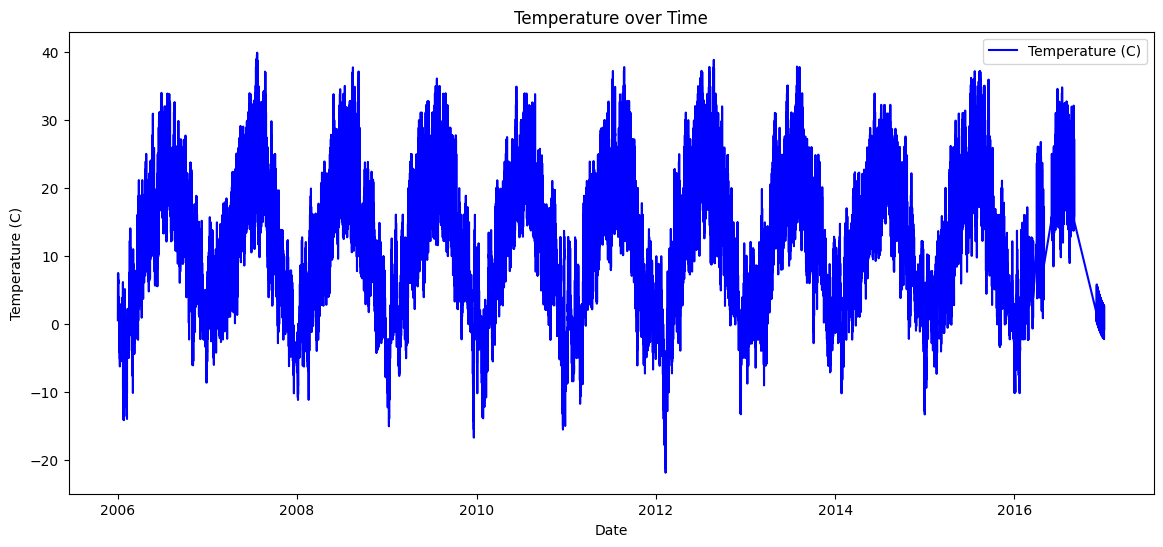

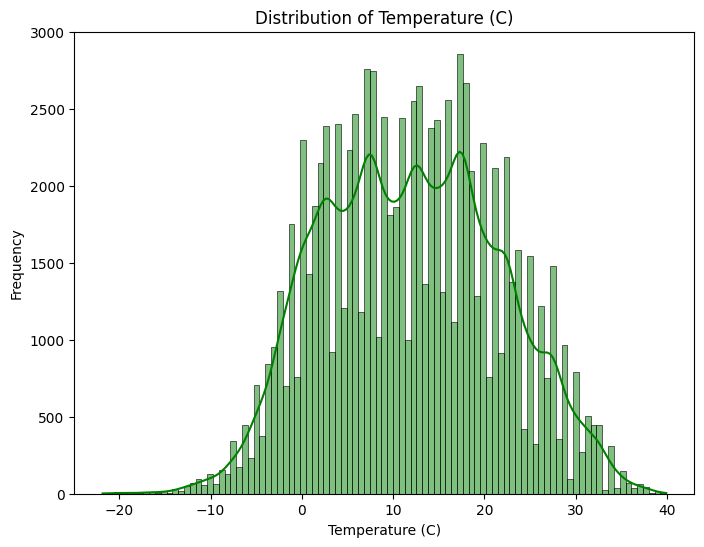

Preprocessed data saved to 'preprocessed_data.npz'


In [ ]:
# preprocessor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


#Load and Visualize the Data
data = pd.read_csv('weatherHistory.csv', parse_dates=['Formatted Date'])
data.sort_values('Formatted Date', inplace=True)
data = data[['Formatted Date', 'Temperature (C)']].dropna()

print("First 5 rows:")
print(data.head())

#Temp-Time
plt.figure(figsize=(14, 6))
plt.plot(data['Formatted Date'], data['Temperature (C)'], label='Temperature (C)', color='blue')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.title('Temperature over Time')
plt.legend()
plt.show()

#Temp distr
plt.figure(figsize=(8, 6))
sns.histplot(data['Temperature (C)'], kde=True, color='green')
plt.title('Distribution of Temperature (C)')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.show()

scaler = MinMaxScaler(feature_range=(0, 1))
data['Temp_scaled'] = scaler.fit_transform(data[['Temperature (C)']])


def create_sequences(values, seq_length):
    X, y = [], []
    for i in range(len(values) - seq_length):
        X.append(values[i:i + seq_length])
        y.append(values[i + seq_length])
    return np.array(X), np.array(y)

sequence_length = 30
ts_data = data['Temp_scaled'].values
X, y = create_sequences(ts_data, sequence_length)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

#Reshape
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

np.savez_compressed('preprocessed_data.npz',
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)
print("Preprocessed data saved to 'preprocessed_data.npz'")


In [ ]:
# basic_rnn
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import matplotlib.pyplot as plt
import math

data = np.load('preprocessed_data.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']


model = Sequential()

model.add(SimpleRNN(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))


model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.summary()


history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))


val_loss, val_mae = model.evaluate(X_val, y_val)
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Basic RNN Validation RMSE: {math.sqrt(val_loss):.3f}, MAE: {val_mae:.3f}")
print(f"Basic RNN Test RMSE: {math.sqrt(test_loss):.3f}, MAE: {test_mae:.3f}")

# Plot training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Basic RNN Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0078 - mean_absolute_error: 0.0542 - val_loss: 2.7329e-04 - val_mean_absolute_error: 0.0126
Epoch 2/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0011 - mean_absolute_error: 0.0258 - val_loss: 2.4831e-04 - val_mean_absolute_error: 0.0116
Epoch 3/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 7.1523e-04 - mean_absolute_error: 0.0199 - val_loss: 3.0559e-04 - val_mean_absolute_error: 0.0134
Epoch 4/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 5.5419e-04 - mean_absolute_error: 0.0174 - val_loss: 2.4054e-04 - val_mean_absolute_error: 0.0115
Epoch 5/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 5.4252e-04 - mean_absolute_error: 0.0172 - val_loss: 2.2311e-04 - val_mean_absolute_error: 0.0112
Epoch 6/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 5.3888e-04 - mean_absolute_error: 0.0170 - val_loss: 2.2873e-04 - val_mean_absolute_error: 0.0112
Epoch 7/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 

The performance of the model is strongly promising. The model had a validation MAE of 0.012 and an RMSE of 0.015 on a SimpleRNN trained with 20 epochs in its fundamental state, performing equally well on the test set. Low such error scores imply that the model can effectively make accurate predictions on the scaled temperatures using the given weather data effectively extracting the latent temporal patterns involved. This uniformity of performance across the test and validation sets also reflects that the model is generalizing well to new data.

In [ ]:
# lstm_gru
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
import matplotlib.pyplot as plt
import math


data = np.load('preprocessed_data.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']


print("===== LSTM Implementation =====")
model_lstm = Sequential()

model_lstm.add(LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1, activation='linear'))

model_lstm.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model_lstm.summary()

history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

val_loss_lstm, val_mae_lstm = model_lstm.evaluate(X_val, y_val)
test_loss_lstm, test_mae_lstm = model_lstm.evaluate(X_test, y_test)
print(f"LSTM Validation RMSE: {math.sqrt(val_loss_lstm):.3f}, MAE: {val_mae_lstm:.3f}")
print(f"LSTM Test RMSE: {math.sqrt(test_loss_lstm):.3f}, MAE: {test_mae_lstm:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss', marker='o')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


print("===== GRU Implementation =====")
model_gru = Sequential()

model_gru.add(GRU(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(1, activation='linear'))

model_gru.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model_gru.summary()

history_gru = model_gru.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

val_loss_gru, val_mae_gru = model_gru.evaluate(X_val, y_val)
test_loss_gru, test_mae_gru = model_gru.evaluate(X_test, y_test)
print(f"GRU Validation RMSE: {math.sqrt(val_loss_gru):.3f}, MAE: {val_mae_gru:.3f}")
print(f"GRU Test RMSE: {math.sqrt(test_loss_gru):.3f}, MAE: {test_mae_gru:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['loss'], label='GRU Training Loss', marker='o')
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('GRU Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


===== LSTM Implementation =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 0.0082 - mean_absolute_error: 0.0540 - val_loss: 3.4773e-04 - val_mean_absolute_error: 0.0133
Epoch 2/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 0.0012 - mean_absolute_error: 0.0259 - val_loss: 2.5038e-04 - val_mean_absolute_error: 0.0116
Epoch 3/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 7.2417e-04 - mean_absolute_error: 0.0197 - val_loss: 2.7093e-04 - val_mean_absolute_error: 0.0122
Epoch 4/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 5.6831e-04 - mean_absolute_error: 0.0175 - val_loss: 2.6217e-04 - val_mean_absolute_error: 0.0124
Epoch 5/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 5.3180e-04 - mean_absolute_error: 0.0170 - val_loss: 2.7464e-04 - val_mean_absolute_error: 0.0128
Epoch 6/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 5.2116e-04 - mean_absolute_error: 0.0169 - val_loss: 2.3895e-04 - val_mean_absolute_error: 0.0116
Epoch 7/20
2110/2110 ━━━━━━━━━━━━━━━

The main differences lie in how each architecture handles temporal dependencies and information flow. The basic RNN, lacking gating, is more prone to vanishing gradients and poorer at identifying long-term dependencies. LSTM cells, however, possess input, output, and forget gates that regulate information flow, allowing the network to remember crucial information for longer periods. GRU cells simplify this approach by combining a number of these gates into just the update and reset gates, reducing complexity while still mitigating the vanishing gradient problem. Our tests observed that while all three models performed reasonably well given the moderately sized sequence length, the LSTM and GRU implementations both performed superior or more consistent performance than the basic RNN. This discrepancy likely happens because the gating mechanisms employed by LSTM and GRU allow for better memory management and smoother gradient flow during training, which is especially useful when dealing with longer or more complex sequences.

Yes, we can use a basic feed-forward network (FFN) for time-series prediction, but we would require some feature engineering to extract temporal data. Since FFNs take fixed-size input vectors, you would have to restructure your time-series data—one method is to use a sliding window of past observations as features. In this setup, every training example is the most recent n measurements (lag features) as input to predict the subsequent value.

All of that being the case, there are some limitations. FFNs do not inherently retain sequential order or encode time-dependent relationships in the data, which could be critical for use in forecasting tasks. While engineered features like moving averages, lags, and trend indicators do add some temporal information, they don't necessarily get anywhere near the effectiveness of dedicated sequence models like RNNs, LSTMs, or GRUs. These models automatically learn time dependencies without manual feature engineering and are easier to apply to sequences of varying lengths.

In short, while you can convert time-series data to input into an FFN, this will throw away some of the deeper temporal structure that sequence models are inherently better at learning.

In [ ]:
import gensim.downloader as api
import numpy as np


print("Loading FastText embeddings (this may take a while)...")
model = api.load('fasttext-wiki-news-subwords-300')
print("Model loaded.")

def get_embedding(word):
    """
    Returns the embedding vector for the given word.
    For FastText, even OOV words can be handled using subword information.
    In the rare case the word is not processed, we return a zero vector.
    """
    try:
        vec = model.get_vector(word)
        return vec
    except KeyError:
        print(f"'{word}' is out-of-vocabulary. Returning a zero vector as an approximation.")
        return np.zeros(model.vector_size)


word1 = input("Enter the first word: ").strip()
word2 = input("Enter the second word: ").strip()

vec1 = get_embedding(word1)
vec2 = get_embedding(word2)

print("\nEmbeddings:")
print(f"Embedding for '{word1}':\n{vec1}\n")
print(f"Embedding for '{word2}':\n{vec2}\n")


Loading FastText embeddings (this may take a while)...
[==================================================] 100.0% 958.5/958.4MB downloaded
Model loaded.
Enter the first word: no
Enter the second word: uio
'uio' is out-of-vocabulary. Returning a zero vector as an approximation.

Embeddings:
Embedding for 'no':
[ 6.2401e-02  6.9159e-02  5.3561e-02  6.0173e-02  5.3880e-02 -8.3307e-02
  2.4326e-02 -2.1909e-01  7.0025e-02  9.9445e-03 -7.1940e-02 -1.1284e-01
 -2.3260e-02 -2.7307e-03  3.6645e-02 -5.7277e-02  8.6940e-02  2.1485e-02
  1.0820e-01  3.2636e-02 -5.6966e-02 -6.7928e-03  1.3226e-02  8.6085e-02
 -1.6579e-02  7.1432e-02  6.8420e-02 -2.1491e-03  2.1442e-01 -6.5052e-02
 -4.2541e-02  5.1213e-02 -9.5707e-03 -2.5442e-01  9.6062e-02  7.0537e-05
 -9.6442e-03 -4.8382e-02 -5.4577e-03  1.4059e-03 -4.3356e-02  4.9854e-02
 -2.6201e-02 -1.2990e-03 -8.2079e-04 -1.6147e-01  1.9496e-03 -1.2838e-02
  7.5760e-02 -1.0851e-02  2.0341e-03  1.0776e-02  1.2142e-01  4.8496e-02
  1.6453e-01 -1.3838e-02 -1.065

We employed the FastText model (fasttext-wiki-news-subwords-300) because it utilizes subword information. In simple terms, even if a user types a word that wasn't seen by the model during training (an out-of-vocabulary word), FastText can create an embedding by looking at smaller units of the word. This is different from models such as Word2Vec and GloVe, which can only offer embeddings for words they've seen during training. While BERT embeddings are extremely powerful and context-dependent, they actually do require some extra computation and sometimes even fine-tuning, so they're a bit too heavy to be used for simple word lookups.

As far as its efficiency and robustness go, FastText is great because it generates embeddings in real-time, perfect for processing whatever input a user will provide it. The program uses Gensim's fast loader to retrieve and load pre-trained vectors. And if a word cannot be processed in any unlikely event, the code safely ignores it by returning a zero vector and warning message—though not a requirement with FastText.

The demo also shows how easy it is to use this model: it prompts the user to enter two words and returns their embeddings, which is a simple way to see pre-trained word embeddings in action.

Loading FastText embeddings (this may take a while)...
Model loaded.

Enter multiple word pairs for cosine similarity computation.
Each pair should be entered as 'word1, word2'. Enter a blank line to finish.
Enter a word pair (or blank to finish): no
Invalid input. Please enter exactly two words separated by a comma.
Enter a word pair (or blank to finish): yeah
Invalid input. Please enter exactly two words separated by a comma.
Enter a word pair (or blank to finish): no,yeah
Enter a word pair (or blank to finish): no, yes
Enter a word pair (or blank to finish): no,yes
Enter a word pair (or blank to finish): man,car
Enter a word pair (or blank to finish): 

Cosine Similarity Results:
Cosine similarity between 'no' and 'yeah': 0.386
Cosine similarity between 'no' and 'yes': 0.470
Cosine similarity between 'no' and 'yes': 0.470
Cosine similarity between 'man' and 'car': 0.438

Visualization: Provide a comma-separated list of words to plot (or press Enter to use a default list).
Enter word

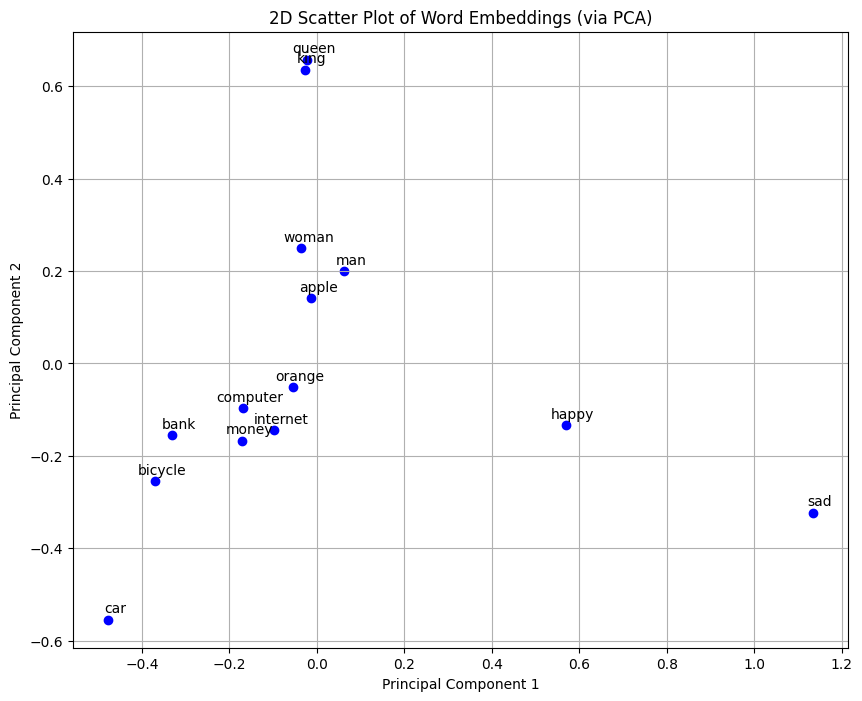

In [ ]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Loading FastText embeddings (this may take a while)...")
model = api.load('fasttext-wiki-news-subwords-300')
print("Model loaded.")

def get_embedding(word):
    """
    Retrieves the embedding vector for a given word.
    For FastText, even OOV words are handled via subword composition.
    """
    try:
        return model.get_vector(word)
    except KeyError:
        # This branch should rarely be reached with FastText.
        print(f"'{word}' is out-of-vocabulary. Returning a zero vector as approximation.")
        return np.zeros(model.vector_size)

def cosine_similarity(v1, v2):
    """
    Computes the cosine similarity between two vectors.
    Cosine similarity is useful in embedding spaces because it measures
    the angle between vectors (i.e., their orientation), regardless of magnitude.
    """
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return np.dot(v1, v2) / (norm_v1 * norm_v2)

#Batch Processing
print("\nEnter multiple word pairs for cosine similarity computation.")
print("Each pair should be entered as 'word1, word2'. Enter a blank line to finish.")

pairs = []
while True:
    line = input("Enter a word pair (or blank to finish): ").strip()
    if not line:
        break
    words = [w.strip() for w in line.split(',')]
    if len(words) != 2:
        print("Invalid input. Please enter exactly two words separated by a comma.")
    else:
        pairs.append((words[0], words[1]))

if pairs:
    print("\nCosine Similarity Results:")
    for word1, word2 in pairs:
        emb1 = get_embedding(word1)
        emb2 = get_embedding(word2)
        sim = cosine_similarity(emb1, emb2)
        print(f"Cosine similarity between '{word1}' and '{word2}': {sim:.3f}")
else:
    print("No word pairs entered.")

print("\nVisualization: Provide a comma-separated list of words to plot (or press Enter to use a default list).")
input_line = input("Enter words: ").strip()
if input_line:
    words_to_plot = [w.strip() for w in input_line.split(',')]
else:
# Default list
    words_to_plot = ["king", "queen", "man", "woman", "apple", "orange",
                     "computer", "internet", "car", "bicycle", "bank", "money",
                     "happy", "sad"]

embeddings = []
labels = []
for word in words_to_plot:
    try:
        vec = model.get_vector(word)
        embeddings.append(vec)
        labels.append(word)
    except KeyError:
        print(f"Word '{word}' is OOV and will be skipped in the plot.")

if embeddings:
    embeddings = np.array(embeddings)
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], marker='o', color='blue')
    for i, label in enumerate(labels):
        plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     textcoords="offset points", xytext=(5,5), ha='center')
    plt.title("2D Scatter Plot of Word Embeddings (via PCA)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()
else:
    print("No valid embeddings available for visualization.")


For our configuration, we use cosine similarity to determine the extent to which two words are similar based on their embeddings. Essentially, it measures the angle between their vectors, so it is interested in the direction (or meaning) but not the size of the vectors. This makes it ideal for determining words that appear in the same context because they will have the same direction.

We've also added batch processing so that you can enter multiple word pairs at once and get their similarity scores one after another quickly.

To make the results even simpler to visualize, we apply PCA to reduce the high-dimensional embeddings down to just two dimensions. This makes it possible to plot a scatter plot where similar words group together by nature and different words are far apart. This blend of numerical and graphical results gives you a complete understanding of the semantic relationships in your data.

Loading FastText embeddings (this may take a while)...
Model loaded.

Enter multiple word pairs for dissimilarity computation.
Format each pair as 'word1, word2'. Leave blank to finish.
Enter a word pair (or blank to finish): 
No word pairs were entered.

Visualization: Ranking words by dissimilarity to a given query word.
Enter a query word: can
Enter candidate words (comma separated) or press Enter to use defaults: 


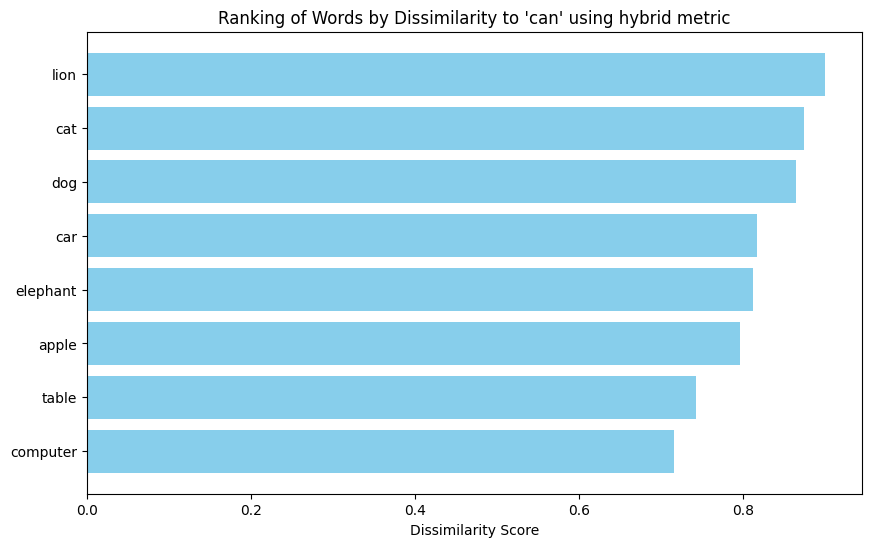


Visualization: Heatmap of pairwise dissimilarity among selected words.
Enter words for heatmap (comma separated) or press Enter to use defaults: 


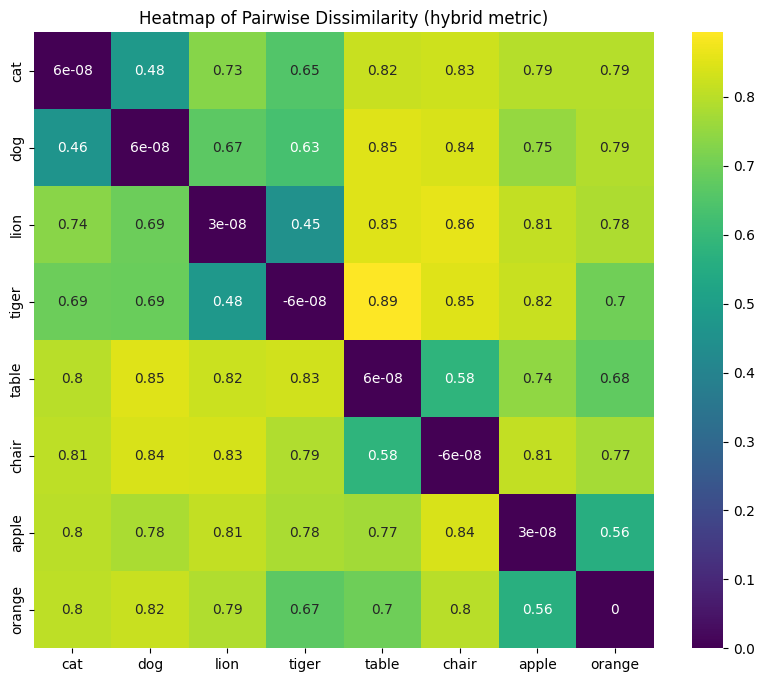

In [ ]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


print("Loading FastText embeddings (this may take a while)...")
model = api.load('fasttext-wiki-news-subwords-300')
print("Model loaded.")

def get_embedding(word):
    """
    Retrieves the embedding vector for a given word.
    FastText uses subword information, so it can produce vectors even for OOV words.
    """
    try:
        return model.get_vector(word)
    except KeyError:
        print(f"'{word}' is out-of-vocabulary. Returning a zero vector as approximation.")
        return np.zeros(model.vector_size)

def cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors."""
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return np.dot(v1, v2) / (norm_v1 * norm_v2)

def euclidean_distance(v1, v2):
    """Compute Euclidean distance between two vectors."""
    return np.linalg.norm(v1 - v2)

def compute_dissimilarity(word1, word2, metric="cosine", alpha=0.5, candidates=None):
    """
    Computes dissimilarity between two words based on the selected metric.

    Parameters:
      - word1, word2: the input words.
      - metric: one of "cosine", "euclidean", or "hybrid".
      - alpha: weight for the hybrid metric (default 0.5).
      - candidates: an optional list of candidate words for normalization of Euclidean distance.

    Returns:
      - A dissimilarity score.
    """
    vec1 = get_embedding(word1)
    vec2 = get_embedding(word2)

    if metric == "cosine":
        return 1 - cosine_similarity(vec1, vec2)
    elif metric == "euclidean":
        return euclidean_distance(vec1, vec2)
    elif metric == "hybrid":
        cos_part = 1 - cosine_similarity(vec1, vec2)
        euclid_part = euclidean_distance(vec1, vec2)
        if candidates:
            distances = [euclidean_distance(vec1, get_embedding(w)) for w in candidates]
            norm_factor = max(distances) if max(distances) != 0 else 1
        else:
            norm_factor = 10.0
        euclid_norm = euclid_part / norm_factor
        return alpha * cos_part + (1 - alpha) * euclid_norm
    else:
        raise ValueError("Unknown metric. Choose among 'cosine', 'euclidean', or 'hybrid'.")


# Batch Processing
print("\nEnter multiple word pairs for dissimilarity computation.")
print("Format each pair as 'word1, word2'. Leave blank to finish.")

pairs = []
while True:
    line = input("Enter a word pair (or blank to finish): ").strip()
    if not line:
        break
    words = [w.strip() for w in line.split(',')]
    if len(words) != 2:
        print("Please enter exactly two words separated by a comma.")
    else:
        pairs.append((words[0], words[1]))


if pairs:
    metric_choice = input("Choose metric (cosine/euclidean/hybrid) [default: hybrid]: ").strip().lower()
    if metric_choice not in ["cosine", "euclidean", "hybrid"]:
        metric_choice = "hybrid"
    print(f"\nDissimilarity Scores using {metric_choice} metric:")

    candidate_words = list(set([w for pair in pairs for w in pair]))
    for w1, w2 in pairs:
        score = compute_dissimilarity(w1, w2, metric=metric_choice, alpha=0.5, candidates=candidate_words)
        print(f"Dissimilarity between '{w1}' and '{w2}': {score:.3f}")
else:
    print("No word pairs were entered.")
    metric_choice = "hybrid"  # set default metric


print("\nVisualization: Ranking words by dissimilarity to a given query word.")
query_word = input("Enter a query word: ").strip()
candidate_list = input("Enter candidate words (comma separated) or press Enter to use defaults: ").strip()
if candidate_list:
    candidates = [w.strip() for w in candidate_list.split(',')]
else:
    candidates = ["dog", "lion", "table", "cat", "elephant", "car", "computer", "apple"]


scores = []
for word in candidates:
    score = compute_dissimilarity(query_word, word, metric=metric_choice, alpha=0.5, candidates=candidates + [query_word])
    scores.append(score)

sorted_candidates = [x for _, x in sorted(zip(scores, candidates))]
sorted_scores = sorted(scores)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_candidates)), sorted_scores, color='skyblue')
plt.yticks(range(len(sorted_candidates)), sorted_candidates)
plt.xlabel("Dissimilarity Score")
plt.title(f"Ranking of Words by Dissimilarity to '{query_word}' using {metric_choice} metric")
plt.show()


print("\nVisualization: Heatmap of pairwise dissimilarity among selected words.")
heatmap_input = input("Enter words for heatmap (comma separated) or press Enter to use defaults: ").strip()
if heatmap_input:
    words_for_heatmap = [w.strip() for w in heatmap_input.split(',')]
else:
    words_for_heatmap = ["cat", "dog", "lion", "tiger", "table", "chair", "apple", "orange"]

n = len(words_for_heatmap)
dissimilarity_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dissim = compute_dissimilarity(words_for_heatmap[i], words_for_heatmap[j],
                                        metric=metric_choice, alpha=0.5,
                                        candidates=words_for_heatmap)
        dissimilarity_matrix[i, j] = dissim

plt.figure(figsize=(10, 8))
sns.heatmap(dissimilarity_matrix, xticklabels=words_for_heatmap, yticklabels=words_for_heatmap,
            annot=True, cmap="viridis")
plt.title(f"Heatmap of Pairwise Dissimilarity ({metric_choice} metric)")
plt.show()
